In [7]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.plotting.plotter_localization import PlotterLocalization
from odometry.point_cloud_processing.vel_filtering import VelFiltering

In [8]:
dataset = radnavDS(
    dataset_path="/data/radnav/rad_nav_filter_experiments/WILK_BASEMENT_1_WALK/",
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder="/data/radnav/maps",
    map_file="wilk_basement.yaml"
)

plotter = PlotterLocalization(dataset,map_handler)

found 1239 radar samples
found 1239 lidar samples
found 1239 camera samples
found 1239 imu (orientation only) samples
found 1239imu (full data) samples
found 1239 vehicle velocity samples
loaded map from /data/radnav/maps/wilk_basement.yaml


0.2409501495421864
(68, 4)


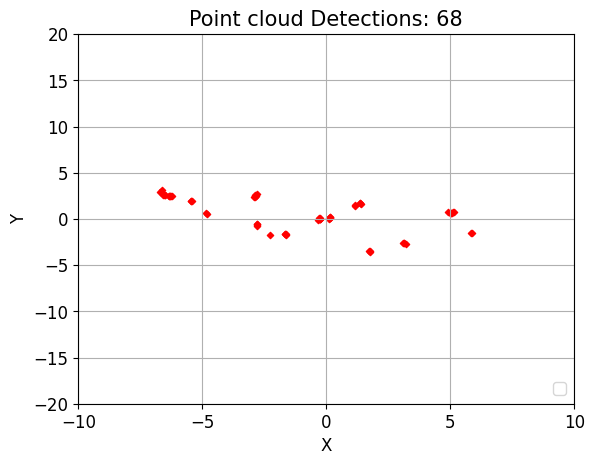

In [9]:
idx = 500

#get the point cloud
ego_x_vel = dataset.get_vehicle_vel_data(idx)[0,1]
vehicle_vel = np.array([ego_x_vel,0.0])
print(ego_x_vel)

#get the detections
detections = dataset.get_radar_detections(idx)
print(detections.shape)

#plot the detections
plotter.plot_detections(detections, show=True)

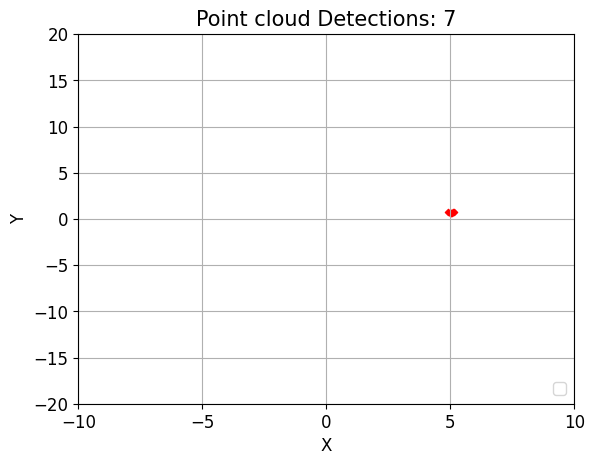

In [10]:
vel_filter = VelFiltering(v_thresh=0.4)

#plot dynamic detections
dynamic_objects = vel_filter.get_dynamic_detections(detections,vehicle_vel)
plotter.plot_detections(dynamic_objects, show=True)

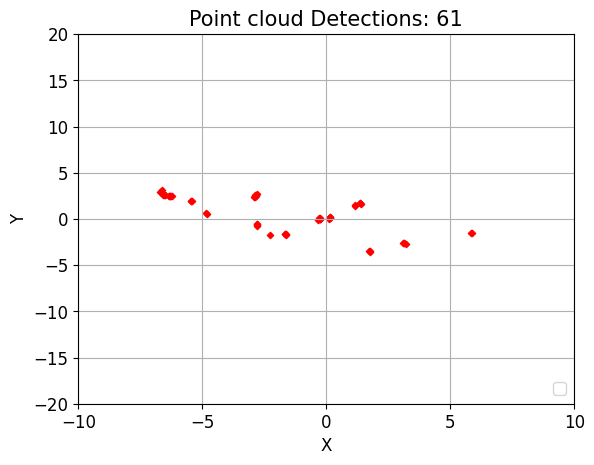

In [11]:
#plot the static objects
static_objects = vel_filter.get_static_detections(detections,vehicle_vel)
plotter.plot_detections(static_objects,show=True)

### Debugging

Useful for looking at what points are being rejected

In [12]:
#predict the velocity measurement
v_pred = vel_filter.predict_vels(detections[:,0:2],vehicle_vel)
print(v_pred)

[ 0.23154388  0.21234037  0.19250335  0.17529075  0.16113435  0.14962374
  0.14985292  0.14967868  0.15780009  0.14835967  0.14823602  0.1074152
  0.10736562  0.10731693  0.18460602  0.18458203  0.1845584   0.1845124
  0.23357098  0.23356943  0.23811923  0.23914201  0.23914142  0.23914087
  0.23914033  0.23811487  0.23811405 -0.2406465  -0.23878618 -0.23647715
 -0.23468738 -0.17093103 -0.17072084 -0.17061639 -0.16235882 -0.23588409
 -0.18724132 -0.1872621  -0.18086926 -0.18083518 -0.18080171 -0.17381742
 -0.22724153 -0.22724137 -0.2272412  -0.224365   -0.22434751 -0.22436313
 -0.22435506 -0.22434706 -0.22432983 -0.2243132  -0.22430564 -0.2243208
 -0.2212634  -0.22123752 -0.2179187  -0.23588409 -0.23429747 -0.23247194
 -0.239216   -0.23920653 -0.22436313 -0.24091692 -0.240925   -0.22899101
 -0.22124091 -0.18884489]


In [13]:
#print the true values
v_true = detections[:,3]
print(detections.shape)
print(v_true)

(68, 4)
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.47384018 -0.47384018 -0.47384018 -0.47384018
 -0.47384018 -0.47384018 -0.47384018  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.24472809  0.24472809  0.24472809
  0.24472809  0.24472809  0.24472809  0.          0.          0.
  0.          0.24472809]


In [14]:

errors = vel_filter.square_error_loss(v_true,v_pred)
print(errors)

[0.05361257 0.04508843 0.03705754 0.03072685 0.02596428 0.02238726
 0.0224559  0.02240371 0.02490087 0.02201059 0.02197392 0.01153802
 0.01152738 0.01151692 0.03407938 0.03407052 0.0340618  0.03404483
 0.0545554  0.05455468 0.5068862  0.50834359 0.50834275 0.50834197
 0.5083412  0.50687999 0.50687882 0.05791074 0.05701884 0.05592144
 0.05507817 0.02921742 0.02914561 0.02910995 0.02636038 0.0556413
 0.03505931 0.03506709 0.03271369 0.03270136 0.03268926 0.0302125
 0.05163871 0.05163864 0.05163856 0.05033965 0.0503318  0.05033882
 0.05033519 0.05033161 0.05032387 0.05031641 0.05031302 0.05031982
 0.04895749 0.04894604 0.04748856 0.23098806 0.22946549 0.22771986
 0.23420188 0.23419272 0.22004658 0.05804096 0.05804486 0.05243688
 0.04894754 0.18798553]
